In [ ]:
# Import required libraries for operations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset and display its shape
df = pd.read_csv("finalapi.csv")
print("Dataset Loaded Successfully")
print("Dataset Shape:",df.shape)


Dataset Loaded Successfully
Dataset Shape: (213328, 49)


In [ ]:
# Print all column names to understand the dataset schema before analysis
print("Columns in Dataset:\n")

for col in df.columns:
    print(col)


Columns in Dataset:

AGENCY_ID
PRIMARY_AGENCY_ID
PROD_ABBR
PROD_LINE
STATE_ABBR
STAT_PROFILE_DATE_YEAR
RETENTION_POLY_QTY
POLY_INFORCE_QTY
PREV_POLY_INFORCE_QTY
NB_WRTN_PREM_AMT
WRTN_PREM_AMT
PREV_WRTN_PREM_AMT
PRD_ERND_PREM_AMT
PRD_INCRD_LOSSES_AMT
MONTHS
RETENTION_RATIO
LOSS_RATIO
LOSS_RATIO_3YR
GROWTH_RATE_3YR
AGENCY_APPOINTMENT_YEAR
ACTIVE_PRODUCERS
MAX_AGE
MIN_AGE
VENDOR_IND
VENDOR
PL_START_YEAR
PL_END_YEAR
COMMISIONS_START_YEAR
COMMISIONS_END_YEAR
CL_START_YEAR
CL_END_YEAR
ACTIVITY_NOTES_START_YEAR
ACTIVITY_NOTES_END_YEAR
CL_BOUND_CT_MDS
CL_QUO_CT_MDS
CL_BOUND_CT_SBZ
CL_QUO_CT_SBZ
CL_BOUND_CT_eQT
CL_QUO_CT_eQT
PL_BOUND_CT_ELINKS
PL_QUO_CT_ELINKS
PL_BOUND_CT_PLRANK
PL_QUO_CT_PLRANK
PL_BOUND_CT_eQTte
PL_QUO_CT_eQTte
PL_BOUND_CT_APPLIED
PL_QUO_CT_APPLIED
PL_BOUND_CT_TRANSACTNOW
PL_QUO_CT_TRANSACTNOW


In [ ]:
#converting 99999 values into NA values
df=df.replace(99999,np.nan)

Task 1: Identify Year-Related Columns

In [ ]:
# Filtering columns containing 'YEAR' in their name and print them
year_cols = [col for col in df.columns if 'YEAR' in col.upper()]
print("Year-Related Columns:\n")
year_columns_df=df[year_cols].copy()
year_columns_df

Year-Related Columns:



,STAT_PROFILE_DATE_YEAR,AGENCY_APPOINTMENT_YEAR,PL_START_YEAR,PL_END_YEAR,COMMISIONS_START_YEAR,COMMISIONS_END_YEAR,CL_START_YEAR,CL_END_YEAR,ACTIVITY_NOTES_START_YEAR,ACTIVITY_NOTES_END_YEAR
0,2005,1957.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,1957.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007,1957.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008,1957.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009,1957.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
213323,2014,1999.0,2002.0,NaN,NaN,NaN,2011.0,NaN,NaN,NaN
213324,2015,1999.0,2002.0,NaN,NaN,NaN,2011.0,NaN,NaN,NaN
213325,2013,1999.0,2002.0,NaN,NaN,NaN,2011.0,NaN,NaN,NaN
213326,2014,1999.0,2002.0,NaN,NaN,NaN,2011.0,NaN,NaN,NaN


Task 2: Missing Values and Range Analysis

In [ ]:
# Build a summary table showing missing value count, missing percentage, min and max year for each year column
summary = []

for col in year_cols:

    summary.append([
        col,
        df[col].isnull().sum(),
        round(df[col].isnull().mean()*100,2),
        df[col].min(),
        df[col].max()
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Column",
        "Missing Values",
        "Missing %",
        "Min Year",
        "Max Year"
    ]
)

summary_df

,Column,Missing Values,Missing %,Min Year,Max Year
0,STAT_PROFILE_DATE_YEAR,0,0.00,2005.0,2015.0
1,AGENCY_APPOINTMENT_YEAR,5639,2.64,1935.0,2015.0
2,PL_START_YEAR,82200,38.53,1994.0,2015.0
3,PL_END_YEAR,209174,98.05,2004.0,2015.0
4,COMMISIONS_START_YEAR,141937,66.53,2003.0,2015.0
5,COMMISIONS_END_YEAR,205604,96.38,2003.0,2015.0
6,CL_START_YEAR,129311,60.62,2011.0,2015.0
7,CL_END_YEAR,204760,95.98,2011.0,2015.0
8,ACTIVITY_NOTES_START_YEAR,171536,80.41,2013.0,2015.0
9,ACTIVITY_NOTES_END_YEAR,209258,98.09,2014.0,2015.0


Task 3: Logical Inconsistency Checks

In [ ]:
# Logical Inconsistency Check 1:
pairs = [
    ('PL_START_YEAR','PL_END_YEAR'),
    ('COMMISIONS_START_YEAR','COMMISIONS_END_YEAR'),
    ('CL_START_YEAR','CL_END_YEAR'),
    ('ACTIVITY_NOTES_START_YEAR','ACTIVITY_NOTES_END_YEAR')
]

for start_col, end_col in pairs:

    invalid = df[df[end_col] < df[start_col]]

    print(f"\n{start_col} vs {end_col}")

    print("Invalid Records:", len(invalid))



PL_START_YEAR vs PL_END_YEAR
Invalid Records: 0

COMMISIONS_START_YEAR vs COMMISIONS_END_YEAR
Invalid Records: 0

CL_START_YEAR vs CL_END_YEAR
Invalid Records: 0

ACTIVITY_NOTES_START_YEAR vs ACTIVITY_NOTES_END_YEAR
Invalid Records: 0


In [ ]:
# Check 2: Future Years (Year > Current Year)
print("\n Check 2: Future Years (Year > 2015)")

year_cols = [col for col in df.columns if 'YEAR' in col.upper()]
current_year = 2015  # max expected year in this dataset

for col in year_cols:
    future = df[df[col] > current_year]
    print(f"\n{col} → Records with year > {current_year}: {len(future)}")



 Check 2: Future Years (Year > 2015)

STAT_PROFILE_DATE_YEAR → Records with year > 2015: 0

AGENCY_APPOINTMENT_YEAR → Records with year > 2015: 0

PL_START_YEAR → Records with year > 2015: 0

PL_END_YEAR → Records with year > 2015: 0

COMMISIONS_START_YEAR → Records with year > 2015: 0

COMMISIONS_END_YEAR → Records with year > 2015: 0

CL_START_YEAR → Records with year > 2015: 0

CL_END_YEAR → Records with year > 2015: 0

ACTIVITY_NOTES_START_YEAR → Records with year > 2015: 0

ACTIVITY_NOTES_END_YEAR → Records with year > 2015: 0


In [ ]:
# Check 3: Unrealistically Old Years (Year < 1900)
print("\n Check 3: Unrealistically Old Years (Year < 1900)")

for col in year_cols:
    old = df[df[col] < 1900]
    print(f"\n{col} → Records with year < 1900: {len(old)}")


 Check 3: Unrealistically Old Years (Year < 1900)

STAT_PROFILE_DATE_YEAR → Records with year < 1900: 0

AGENCY_APPOINTMENT_YEAR → Records with year < 1900: 0

PL_START_YEAR → Records with year < 1900: 0

PL_END_YEAR → Records with year < 1900: 0

COMMISIONS_START_YEAR → Records with year < 1900: 0

COMMISIONS_END_YEAR → Records with year < 1900: 0

CL_START_YEAR → Records with year < 1900: 0

CL_END_YEAR → Records with year < 1900: 0

ACTIVITY_NOTES_START_YEAR → Records with year < 1900: 0

ACTIVITY_NOTES_END_YEAR → Records with year < 1900: 0


In [ ]:
# Check 4: Same Start and End Year (Zero Duration)
print("\n Check 4: Same Start and End Year (Zero Duration)")
pairs = [
    ('PL_START_YEAR','PL_END_YEAR'),
    ('COMMISIONS_START_YEAR','COMMISIONS_END_YEAR'),
    ('CL_START_YEAR','CL_END_YEAR'),
    ('ACTIVITY_NOTES_START_YEAR','ACTIVITY_NOTES_END_YEAR')
]
for start_col, end_col in pairs:
    same = df[df[start_col] == df[end_col]]
    print(f"\n{start_col} vs {end_col} → Same year records: {len(same)}")


 Check 4: Same Start and End Year (Zero Duration)

PL_START_YEAR vs PL_END_YEAR → Same year records: 419

COMMISIONS_START_YEAR vs COMMISIONS_END_YEAR → Same year records: 1704

CL_START_YEAR vs CL_END_YEAR → Same year records: 6270

ACTIVITY_NOTES_START_YEAR vs ACTIVITY_NOTES_END_YEAR → Same year records: 1902


In [ ]:
# Check 5: Agency Appointment Year > Profile Year
# (Agency appointed AFTER profile was recorded — impossible)
print("\n Check 5: Agency Appointment Year > Profile Date Year")
invalid_appt = df[df['AGENCY_APPOINTMENT_YEAR'] > df['STAT_PROFILE_DATE_YEAR']]
print(f"\n AGENCY_APPOINTMENT_YEAR > STAT_PROFILE_DATE_YEAR → Invalid Records: {len(invalid_appt)}")


 Check 5: Agency Appointment Year > Profile Date Year

 AGENCY_APPOINTMENT_YEAR > STAT_PROFILE_DATE_YEAR → Invalid Records: 0


In [ ]:
# Check 6: PL Start Year > Profile Date Year
# (Policy started AFTER profile year — suspicious)
print("\nCheck 6: PL Start Year > Profile Date Year")
invalid_pl = df[df['PL_START_YEAR'] > df['STAT_PROFILE_DATE_YEAR']]
print(f"\n PL_START_YEAR > STAT_PROFILE_DATE_YEAR → Suspicious Records: {len(invalid_pl)}")



Check 6: PL Start Year > Profile Date Year

 PL_START_YEAR > STAT_PROFILE_DATE_YEAR → Suspicious Records: 27254


Task 4: Selection of Year Field

In [ ]:
# Select STAT_PROFILE_DATE_YEAR as the most reliable year field for further analysis
selected_year = 'STAT_PROFILE_DATE_YEAR'

print("Selected Year Field:")
print(selected_year)

Selected Year Field:
STAT_PROFILE_DATE_YEAR


Justification:

STAT_PROFILE_DATE_YEAR was selected because it represents the reporting year of agency performance records. It contains no missing values, has a realistic year range (2005–2015), and is directly relevant for trend analysis. Unlike several other year fields, it does not contain placeholder values such as 99999.

Task 5: Record Count by Year

In [ ]:
# Group records by the selected year field and count the number of records per year
year_counts = (
    df.groupby('STAT_PROFILE_DATE_YEAR')
      .size()
      .sort_index()
)

print(year_counts)

STAT_PROFILE_DATE_YEAR
2005    16419
2006    17685
2007    18772
2008    20228
2009    18343
2010    19240
2011    19812
2012    21922
2013    19412
2014    20514
2015    20981
dtype: int64


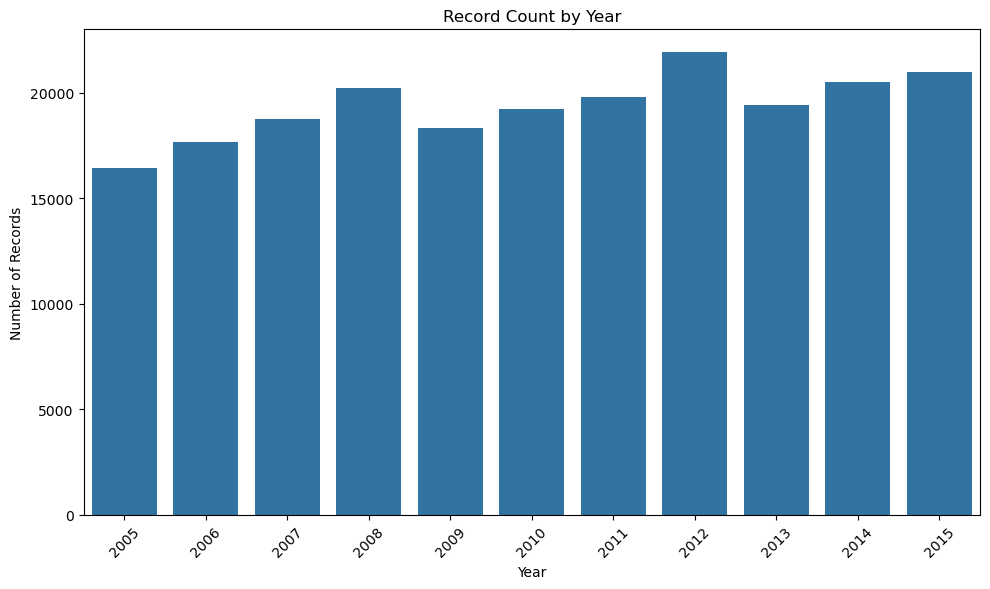

In [ ]:
# Plotting a bar chart showing record count for each year
plt.figure(figsize=(10,6))

sns.barplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title("Record Count by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

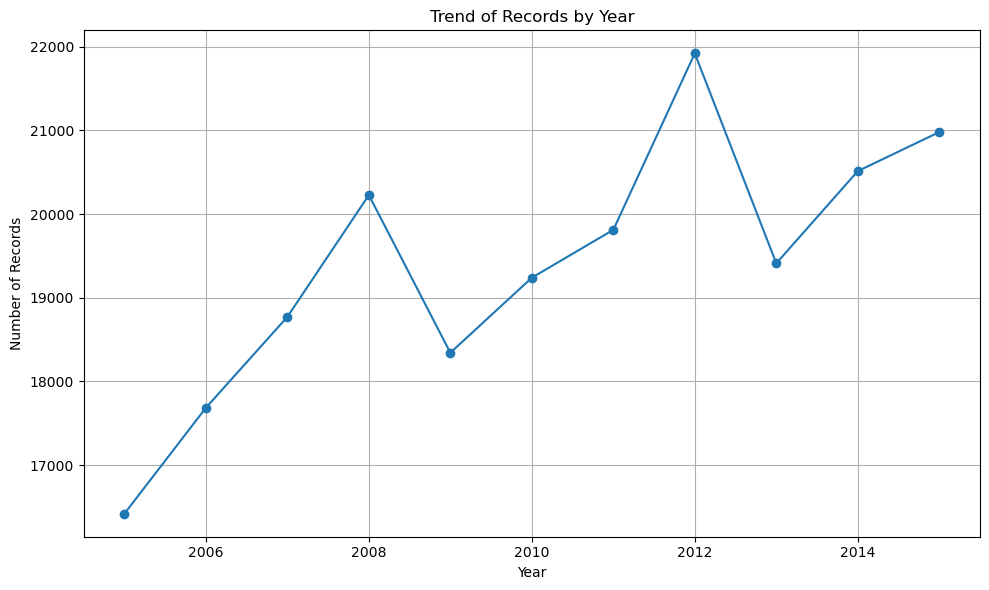

In [ ]:
# Plotting a line chart to show the trend of records over the years
plt.figure(figsize=(10,6))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker='o'
)

plt.title("Trend of Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.grid(True)
plt.tight_layout()
plt.show()